## 1. 파이토치로 단층 퍼셉트론 구현하기

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [ ]:
device = 'xpu' if torch.xpu.is_available() else 'cpu'
print(f'Using device: {device}')

torch.manual_seed(777)
if device == 'xpu':
    torch.xpu.manual_seed_all(777)

In [ ]:
X = torch.FloatTensor([[0, 0], [0, 1], [1, 0], [1, 1]]).to(device)
Y = torch.FloatTensor([[0], [1], [1], [0]]).to(device)

In [ ]:
linear = nn.Linear(2, 1, bias=True)
sigmoid = nn.Sigmoid()
model = nn.Sequential(linear, sigmoid).to(device)

In [ ]:
# 비용 함수와 옵티마이저 정의
loss = torch.nn.BCELoss().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=1)

### 1.1 단층 퍼셉트론의 한계
- [06-01](../06.%20Artificial%20Neural%20Network/06-01.%20machine_learning_basics.ipynb)에서 확인했듯이, 단층 퍼셉트론으로는 XOR 게이트를 구현할 수 없다.
- 200번째의 에포크 이후로 손실값이 줄어들지 않은 것을 볼 수 있다.
- 훈련이 완료된 모델의 예측값을 보아도 예측이 제대로 이루어지지 않는다.

In [ ]:
losses = []

for step in range(10001):
    optimizer.zero_grad()
    hypothesis = model(X)

    # 비용 함수
    cost = loss(hypothesis, Y)
    losses.append(cost.item())
    cost.backward()
    optimizer.step()

    if step % 100 == 0: # 100번째 에포크마다 비용 출력
        print(step, cost.item())

plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.show()

In [ ]:
with torch.no_grad():
    hypothesis = model(X)
    predicted = (hypothesis > 0.5).float()
    accuracy = (predicted == Y).float().mean()
    print('모델의 출력값(Hypothesis): ', hypothesis.detach().cpu().numpy())
    print('모델의 예측값(Predicted): ', predicted.detach().cpu().numpy())
    print('실제값(Y): ', Y.cpu().numpy())
    print('정확도(Accuracy): ', accuracy.item())

## 2. 파이토치로 다층 퍼셉트론 구현하기


In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [ ]:
device = 'xpu' if torch.xpu.is_available() else 'cpu'

# for reproducibility
torch.manual_seed(777)
if device == 'xpu':
    torch.xpu.manual_seed_all(777)

In [ ]:
X = torch.FloatTensor([[0, 0], [0, 1], [1, 0], [1, 1]]).to(device)
Y = torch.FloatTensor([[0], [1], [1], [0]]).to(device)

In [ ]:
model = nn.Sequential(
          nn.Linear(2, 10, bias=True), # input_layer = 2, hidden_layer1 = 10
          nn.Sigmoid(), # 1st hidden layer activation
          nn.Linear(10, 10, bias=True), # hidden_layer1 = 10, hidden_layer2 = 10
          nn.Sigmoid(), # 2nd hidden layer activation
          nn.Linear(10, 10, bias=True), # hidden_layer2 = 10, hidden_layer3 = 10
          nn.Sigmoid(), # 3rd hidden layer activation
          nn.Linear(10, 1, bias=True), # hidden_layer3 = 10, output_layer = 1
          nn.Sigmoid() # output layer activation
          ).to(device)

In [ ]:
loss = torch.nn.BCELoss().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=1)  # modified learning rate from 0.1 to 1

### 2.1 다층 퍼셉트론의 적용
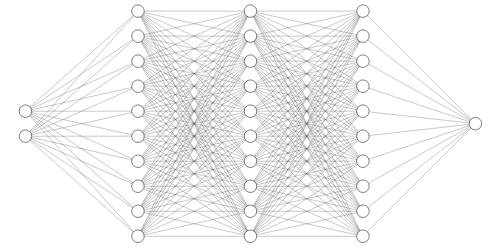

In [ ]:
losses = []

for epoch in range(10001):
    optimizer.zero_grad()
    # forward 연산
    hypothesis = model(X)

    # 비용 함수
    cost = loss(hypothesis, Y)
    losses.append(cost.item())
    cost.backward()
    optimizer.step()

    # 100의 배수에 해당되는 에포크마다 비용을 출력
    if epoch % 100 == 0:
        print(epoch, cost.item())

plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.show()

In [ ]:
with torch.no_grad():
    hypothesis = model(X)
    predicted = (hypothesis > 0.5).float()
    accuracy = (predicted == Y).float().mean()
    print(f'모델의 출력값(Hypothesis): \n{hypothesis.detach().cpu().numpy()}\n')
    print(f'모델의 예측값(Predicted): \n{predicted.detach().cpu().numpy()}\n')
    print(f'실제값(Y): \n{Y.cpu().numpy()}\n')
    print(f'정확도(Accuracy): {accuracy.item()}')